In [1]:
import os

os.environ['KAGGLE_USERNAME'] = 'aishik996'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_61236d6a08ac73ba31896583260ad688'

In [2]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown




  0%|          | 0.00/1.06G [00:00<?, ?B/s]
  0%|          | 1.00M/1.06G [00:01<29:49, 638kB/s]
  0%|          | 2.00M/1.06G [00:01<14:48, 1.28MB/s]
  0%|          | 3.00M/1.06G [00:02<09:11, 2.07MB/s]
  0%|          | 5.00M/1.06G [00:02<04:50, 3.92MB/s]
  1%|          | 7.00M/1.06G [00:02<03:06, 6.09MB/s]
  1%|          | 9.00M/1.06G [00:02<02:22, 7.97MB/s]
  1%|          | 11.0M/1.06G [00:02<01:53, 9.99MB/s]
  1%|          | 13.0M/1.06G [00:02<01:40, 11.3MB/s]
  1%|▏         | 15.0M/1.06G [00:02<01:27, 13.0MB/s]
  2%|▏         | 17.0M/1.06G [00:02<01:20, 13.9MB/s]
  2%|▏         | 19.0M/1.06G [00:03<01:20, 14.0MB/s]
  2%|▏         | 21.0M/1.06G [00:03<01:15, 14.8MB/s]
  2%|▏         | 23.0M/1.06G [00:03<01:28, 12.6MB/s]
  2%|▏         | 26.0M/1.06G [00:03<01:17, 14.4MB/s]
  3%|▎         | 28.0M/1.06G [00:03<01:20, 13.8MB/s]
  3%|▎         | 30.0M/1.06G [00:03<01:27, 12.7MB/s]
  3%|▎         | 32.0M/1.06G [00:04<01:32, 12.0MB/s]
  3%|▎         | 34.0M/1.06G [00:04<01:37, 11.4MB/s]
  

In [4]:
import zipfile

with zipfile.ZipFile('dogsvscats.zip','r')as zip_ref:
  zip_ref.extractall('data')

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

In [9]:
#generators

train_ds=keras.utils.image_dataset_from_directory(
    directory='data/catsvsdogs/train',
    labels='inferred',
    image_size=(256,256),
    batch_size=32,
    label_mode='int'
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='data/catsvsdogs/test',
    labels='inferred',
    image_size=(256,256),
    batch_size=32,
    label_mode='int'
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [10]:
def process(image,label):
  image=tf.cast(image/255.0,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [11]:
#creating model

model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

          

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\aishik.biswas\AppData\Local\anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,761 (56.64 MB)

 Trainable params: 14,847,761 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [18]:
model.fit(train_ds,epochs=20,validation_data=(validation_ds))

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 498s 796ms/step - accuracy: 0.5730 - loss: 0.6700 - val_accuracy: 0.6690 - val_loss: 0.5931
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 508s 813ms/step - accuracy: 0.7194 - loss: 0.5426 - val_accuracy: 0.7674 - val_loss: 0.4895
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 500s 800ms/step - accuracy: 0.8031 - loss: 0.4249 - val_accuracy: 0.7898 - val_loss: 0.4436
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 487s 779ms/step - accuracy: 0.8688 - loss: 0.3038 - val_accuracy: 0.8004 - val_loss: 0.4718
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 485s 776ms/step - accuracy: 0.9327 - loss: 0.1711 - val_accuracy: 0.7970 - val_loss: 0.6461
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 486s 778ms/step - accuracy: 0.9639 - loss: 0.0921 - val_accuracy: 0.7984 - val_loss: 0.7279
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 484s 775ms/step - accuracy: 0.9779 - loss: 0.0631 - val_accuracy: 0.7934 - val_loss: 0.8450
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 487s 778ms/step - accuracy: 0.9818 -

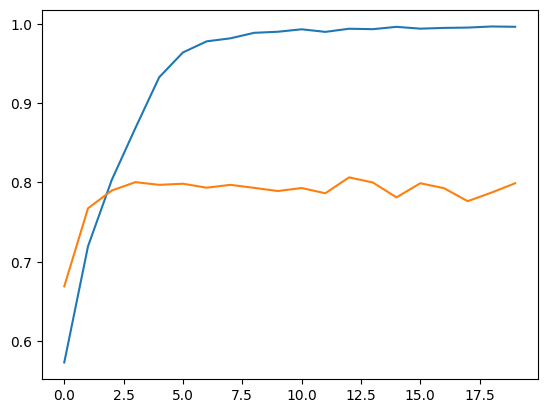

In [20]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'],label='accuracy')
plt.plot(model.history.history['val_accuracy'],label='val_accuracy')
plt.show()

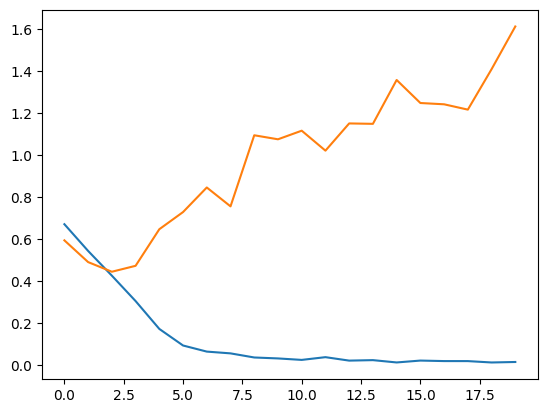

In [22]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'],label='accuracy')
plt.plot(model.history.history['val_loss'],label='val_accuracy')
plt.show()

In [1]:
import pandas as np